In [4]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv(r"C:\Users\bharg\OneDrive\Desktop\loan prediction via sml\datasets\Loan Eligibility Prediction.csv")

In [3]:
df.columns

Index(['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status'],
      dtype='object')

In [15]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": "Approved", "N": "Rejected"})

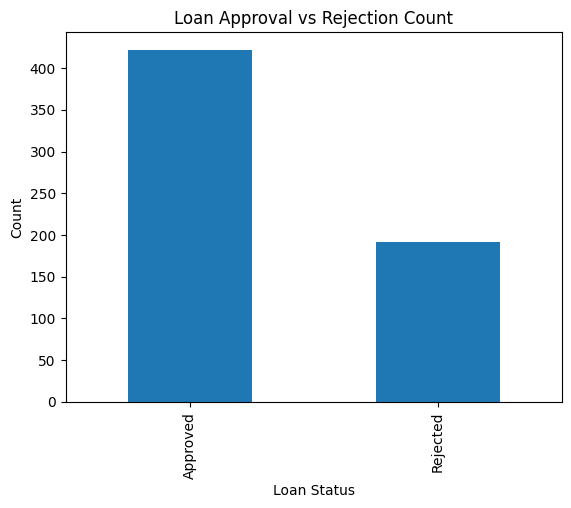

In [16]:
status_counts = df["Loan_Status"].value_counts()

plt.figure()
status_counts.plot(kind="bar")
plt.title("Loan Approval vs Rejection Count")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


<Figure size 640x480 with 0 Axes>

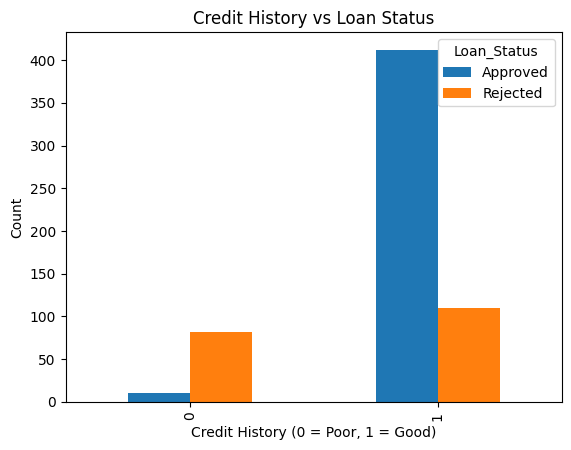

In [17]:
credit_status = pd.crosstab(df["Credit_History"], df["Loan_Status"])

plt.figure()
credit_status.plot(kind="bar")
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History (0 = Poor, 1 = Good)")
plt.ylabel("Count")
plt.show()


<Figure size 640x480 with 0 Axes>

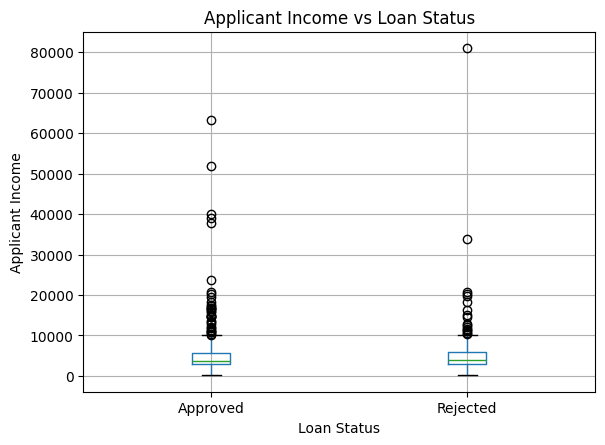

In [18]:
plt.figure()
df.boxplot(column="Applicant_Income", by="Loan_Status")
plt.title("Applicant Income vs Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()


<Figure size 640x480 with 0 Axes>

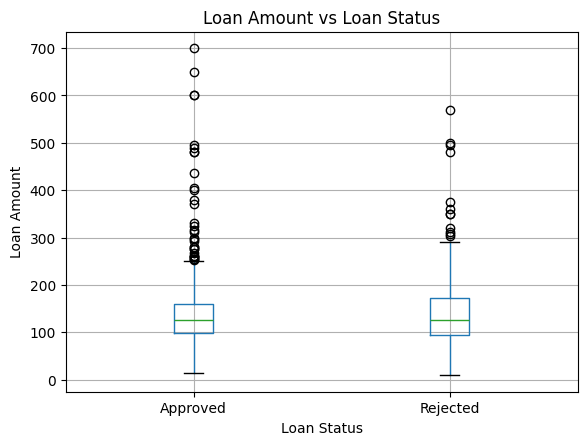

In [19]:
plt.figure()
df.boxplot(column="Loan_Amount", by="Loan_Status")
plt.title("Loan Amount vs Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()


<Figure size 640x480 with 0 Axes>

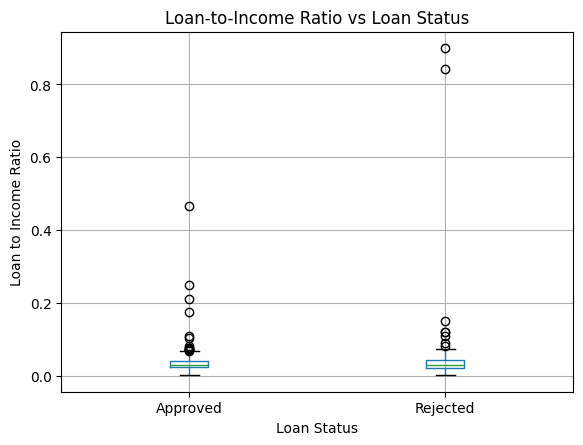

In [20]:
df["Loan_to_Income"] = df["Loan_Amount"] / df["Applicant_Income"]
plt.figure()
df.boxplot(column="Loan_to_Income", by="Loan_Status")
plt.title("Loan-to-Income Ratio vs Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Loan to Income Ratio")
plt.show()


<Figure size 640x480 with 0 Axes>

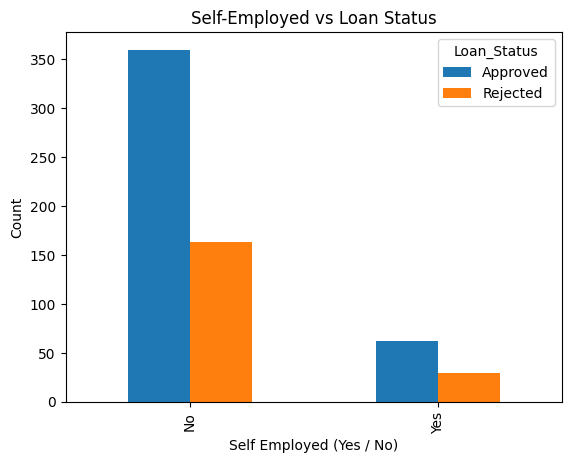

In [21]:
emp_status = pd.crosstab(df["Self_Employed"], df["Loan_Status"])

plt.figure()
emp_status.plot(kind="bar")
plt.title("Self-Employed vs Loan Status")
plt.xlabel("Self Employed (Yes / No)")
plt.ylabel("Count")
plt.show()


<Figure size 640x480 with 0 Axes>

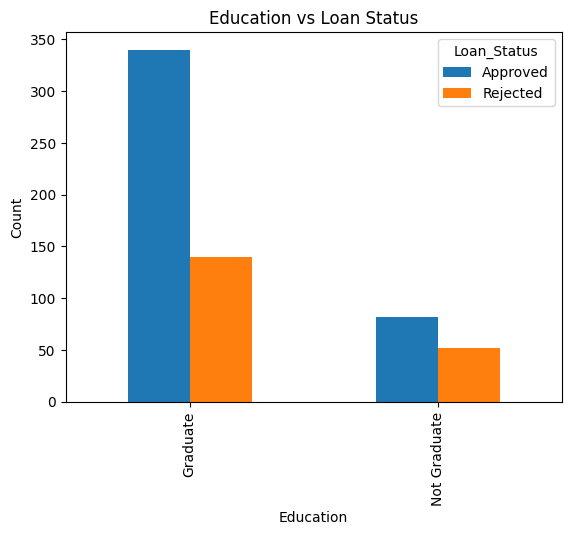

In [22]:
edu_status = pd.crosstab(df["Education"], df["Loan_Status"])

plt.figure()
edu_status.plot(kind="bar")
plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()


<Figure size 640x480 with 0 Axes>

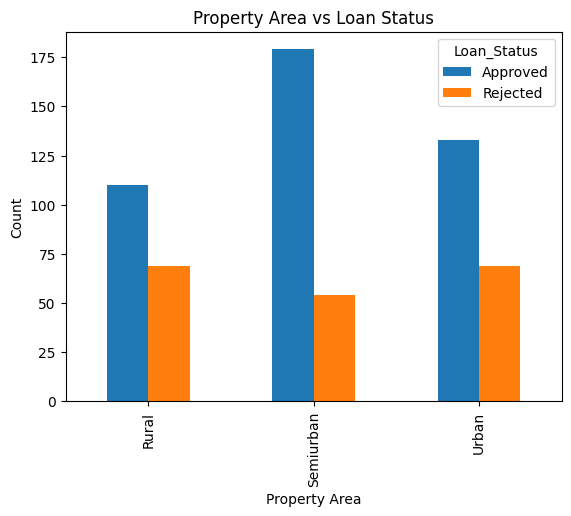

In [23]:
area_status = pd.crosstab(df["Property_Area"], df["Loan_Status"])

plt.figure()
area_status.plot(kind="bar")
plt.title("Property Area vs Loan Status")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.show()


In [24]:
grouped = df.groupby(
    ["Credit_History", pd.cut(df["Loan_to_Income"], bins=3)]
)["Loan_Status"].value_counts().unstack()

print(grouped)


Loan_Status                       Approved  Rejected
Credit_History Loan_to_Income                       
0              (0.000311, 0.301]        10        82
               (0.301, 0.6]              0         0
               (0.6, 0.9]                0         0
1              (0.000311, 0.301]       411       108
               (0.301, 0.6]              1         0
               (0.6, 0.9]                0         2


C:\Users\bharg\AppData\Local\Temp\ipykernel_10816\1258018570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(
